# Математическая статистика для анализа больших данных
## Задание 1
### Свойства оценок и доверительные интервалы

Выполненную работу нужно отправить телеграм-боту  `@stats_bd_bot`
* Дедлайн см. в телеграм-боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* По практическим задачам прислать нужно ноутбук в формате `ipynb`.
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Не забывайте делать пояснения и выводы.
* Решение теоретических задач можете записывать в markdown с помощью TeX, присылать в виде фотографий или вшивать в ноутбук через Insert Image (убеждайтесь, что картинка сохраняется при перемещении ноутбука в другое место)

___
### Задача 1

Ученые задались вопросом, какую максимальную длину хвоста может иметь обычный московский кот. Для этого они в разных частях города отловили $n$ котов и измерили длину их хвоста. Ученые сделали предположение, что полученные измерения являются выборкой $X_1,\ldots,X_n$ из распределения $U(0,\theta)$. Проверьте на несмещенность и состоятельность следующие оценки параметра $\theta$ (сильную состоятельность проверять не обязательно):

$2\overline{X}$, $X_{(n)}$

$2\overline{X}$ -- несмещённая:\
$$\mathsf{E}_\theta 2\overline{X} = \frac{2}{n} \sum_{i=1}^n \mathsf{E}_\theta X_i =  2  \mathsf{E}_\theta X_1 = \theta$$

$X_{(n)}$ -- не несмещенная:

$$ F_{X_{(n)}}(x) = P(X_{(n)} < x) = \prod\limits_{i = 1}^n P(X_i < x) = P(X_1 < x)^n =
\begin{cases}
  0, &  x < 0 \\
  \frac{x^n}{\theta^n}, & x \in [0,  \theta]\\
  1, & иначе
\end{cases}
$$

Тогда
$$ p_{X_{(n)}} (x) = [F_{X_{(n)}}(x)]' = n \frac{x^{n-1}}{\theta^n} $$

$$\mathsf{E}_\theta X_{(n)} = n\int_0^\theta x \frac{x^{n-1}}{\theta^n} dx = \frac{n}{\theta^n} \int_0^\theta x^{n} = \frac{n\theta^{n+1}}{(n+1)\theta^n} = \frac{n\theta}{(n+1)} $$

$2\overline{X}$ -- состоятельная:\
По ЗБЧ
$$2\overline{X} ⟶ 2 \theta/2 = \theta$$
Она сильно состоятельная, а значит и состоятельная.

$X_{(n)}$ -- состоятельная:

$$∀ϵ>0: P(|X_{(n)}-\theta| > ϵ)=P( X_{(n)} < \theta - ϵ) = \prod\limits_{i = 1}^n P(X_i < \theta - ϵ) = (\frac{θ - ϵ}{θ})^n = (1 - \frac{ϵ}{\theta})^n = 0$$


Подсказки:

* Распределение порядковых статистик проще выводить через функцию распределения (а затем считать плотность и математическое ожидание)

$$ F_{X_{(n)}}(x) = P(X_{(n)} < x) = \prod\limits_{i = 1}^n P(X_i < x) = \dots $$

* Для проверки состоятельности может быть нужно воспользоваться определением сходимости по вероятности

___
### Задача 2

 В данном задании вам нужно изучить доверительные интервалы для параметра сдвига в нормальной модели в случае неизвестной дисперсии.

$$X_1, X_2, \dots, X_n \sim \mathcal{N}(\theta, \sigma^2),\  \sigma^2 \text{ неизвестна}
$$

 Требуется построить:
 * асимтотический доверительный интервал при помощи центральной предельной теоремы и леммы Слуцкого;

 $$ \theta \in \left(\overline{X} - \frac{S}{\sqrt{n}} z_{(1 + \alpha) / 2}, \overline{X} + \frac{S}{\sqrt{n}} z_{(1 + \alpha) / 2} \right) $$

 * точный неасимптотический при помощи распределений хи-квадрат, Стьюдента.

 $$ \theta \in \left(\overline{X} - \frac{S}{\sqrt{n - 1}} T_{n-1, (1+\alpha)/2}, \overline{X} + \frac{S}{\sqrt{n - 1}} T_{n-1, (1+\alpha)/2}\right) $$

 Тут $S = \sqrt{S^2}$, $T_{n, \alpha}$ &mdash; $\alpha$-квантиль распределения Стьюдента с $n$ степенями свободы.

Реализуйте функции построения этих интервалов по выборке. Задокументируйте функции (см. [гайд](https://realpython.com/documenting-python-code/)).

*Напоминание*: для асимптотического интервала требуемое условие на вероятность принадлежности $\theta$ интервалу выполняется только в пределе при больших размерах выборки. Ваша задача увидеть этот эффект и сравнить асимптотический интервал с точным.

In [69]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid', font_scale=1.6)

%matplotlib inline

In [129]:
def calculate_asymptotic_confidence_intervals(sample, alpha=0.95):
    """Возвращает границы левого и правого
    асимптотического доверительного интервала.
    :param sample: выборка
    :param alpha: уровень значимости
    :return: кортеж (левая граница, правая граница)
    """
    S = np.std(sample, ddof=1)
    z = sps.norm.ppf((1 + alpha) / 2)
    n = len(sample)

    left = sample.mean() - (S / np.sqrt(n)) * z
    right = sample.mean() + (S / np.sqrt(n)) * z

    return left, right


def calculate_confidence_intervals(sample, alpha=0.95):
    """
    Возвращает границы левого и правого точного доверительного интервала.

    :param sample: выборка
    :param alpha: уровень значимости
    :return: кортеж (левая граница, правая граница)
    """
    S = np.std(sample, ddof=1)
    n = len(sample)
    mean = np.mean(sample)
    t_quantile = sps.t.ppf((1 + alpha) / 2, df=n-1)
    margin = (S / np.sqrt(n)) * t_quantile

    left = mean - margin
    right = mean + margin

    return left, right

Сгенерируйте выборку из нормального расределения и сравните два доверительных интервала в зависимости от размера выборки. Для сравнения отобразите оба интервала на одном графике. Проследите за тем, чтобы было видно, как соотносятся размеры интервалов. Поясните теоретическую причину такого поведения доверительных интервалов.

*Указание*: рассматривайте длину выборки около 20-30.

In [134]:
def draw_confidence_interval(
    left, right, estimation=None, sample=None,
    ylim=(None, None), color_estimation='#FF3300',
    color_interval='#00CC66',
    color_sample='#0066FF', label_estimation='Оценка',
    label_interval='Доверительный интервал'
):
    """Рисует доверительный интервал
    и оценку в зависимости от размера выборки.

    :param left: левые границы интервалов (в зависимости от n)
    :param right: правые границы интервалов (в зависимости от n)
    :param estimation: оценки (в зависимости от n)
    :param sample: выборка
    :param ylim: ограничение вертикальной оси
    :param color_estimation: цвет оценки
    :param color_interval: цвет интервала
    :param color_sample: цвет выборки
    :param label_estimation: подпись к графику
    """

    time = np.arange(len(left)) + 1

    assert len(time) == len(right)

    if not sample is None:
        plt.scatter(time, sample, alpha=0.3, color=color_sample,
                    s=40, label='Элемент выборки')

    if not estimation is None:
        plt.plot(time, estimation, color=color_estimation,
                 linewidth=2.5, label=label_estimation)

    plt.fill_between(time, left, right, alpha=0.4, \
                     color=color_interval, label=label_interval)

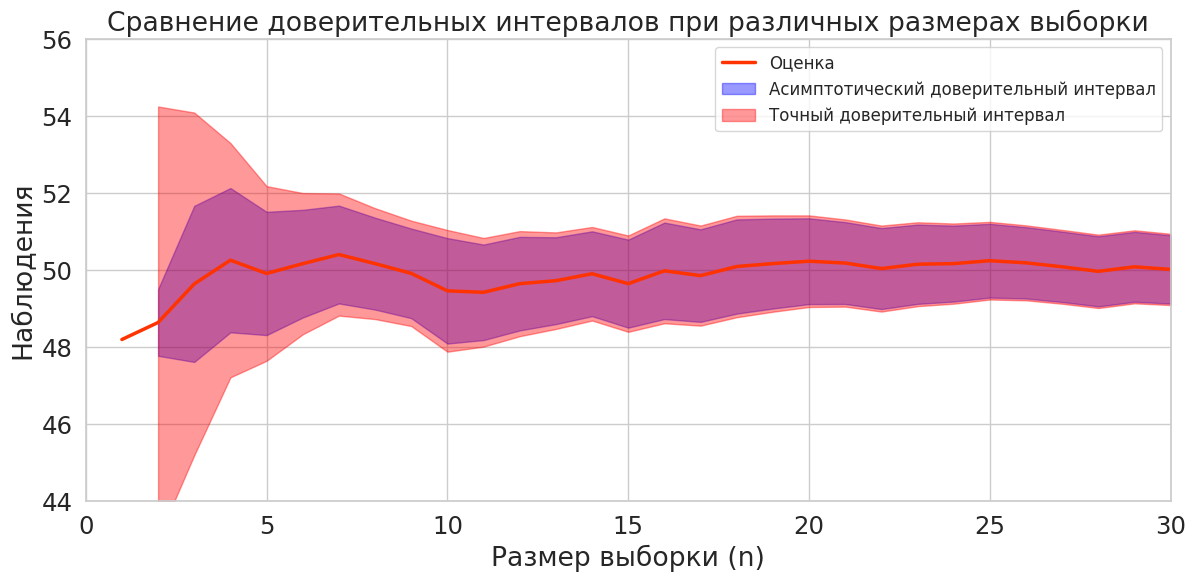

In [163]:
theta = 50
sigma = 3
size = 30
sample_length = range(1, size+1)
sample = sps.norm.rvs(loc=theta, scale=sigma, size=size)
alpha = 0.95
estimation = sample.cumsum() / size

asym_lefts = np.array([])
asym_rights = np.array([])

plt.figure(figsize=(14,6))


time = np.arange(len(sample)) + 1
estimation = sample.cumsum() / time

for i in sample_length:
  asym_left, asym_right = \
  calculate_asymptotic_confidence_intervals(sample[:i], alpha)
  asym_lefts = np.append(asym_lefts, asym_left)
  asym_rights = np.append(asym_rights, asym_right)

draw_confidence_interval(
    left=asym_lefts,
    right=asym_rights,
    estimation=estimation,
    sample=None,
    color_interval='blue',
    label_interval='Асимптотический доверительный интервал'
)

exaxt_lefts = np.array([])
exact_rights = np.array([])

for i in sample_length:
  exaxt_left, exact_right = \
  calculate_confidence_intervals(sample[:i], alpha)
  exaxt_lefts = np.append(exaxt_lefts, exaxt_left)
  exact_rights = np.append(exact_rights, exact_right)

draw_confidence_interval(
    left=exaxt_lefts,
    right=exact_rights,
    estimation=None,
    sample=None,
    color_interval='red',
    label_interval='Точный доверительный интервал'
)

plt.legend(fontsize=12)
plt.xlim((0, 30))
plt.ylim((theta - 2 * sigma, theta + 2 * sigma))
plt.xlabel('Размер выборки (n)')
plt.ylabel('Наблюдения')
plt.title('Сравнение доверительных интервалов \
при различных размерах выборки')
plt.grid(True)
plt.show()

**Вывод:** при малых выборках точный интервал шире, так как учитывает неопределенность малых данных. Асимптотический интервал короче, потому что основан на приближении, работающем хуже при малых выборках. С увеличением размера выборки, оба интервала сокращаются, но асимптотический остается короче из-за приближения к нормальному распределению.

Cкачайте данные <a href="http://archive.ics.uci.edu/ml/datasets/wine">`wine dataset`</a> и рассмотрите столбцы `Alcalinity of ash`, `Nonflavanoid phenols`, `Proanthocyanins` и `Hue` для вина *первого типа*. Тип вина указан в первом столбце.

Постройте доверительные интервалы для параметров сдвига каждого из столбцов, предполагая, что столбцы имеют нормальное распределение. Нужно построить доверительные интервалы обоих рассмотренных выше типов. Запишите их в виде таблицы.

In [161]:
import pandas as pd
import numpy as np
from scipy import stats

url = '/content/wine.data'
columns = ['Type', 'Alcohol', 'Malic_acid', 'Ash', \
           'Alcalinity_of_ash', 'Magnesium',
           'Total_phenols', 'Flavanoids', 'Nonflavanoid_phenols', \
           'Proanthocyanins',
           'Color_intensity', 'Hue', 'OD280_OD315', 'Proline']
data = pd.read_csv(url, header=None, names=columns)

wine_type1 = data[data['Type'] == 1]
columns_for_analysis = ['Alcalinity_of_ash', 'Nonflavanoid_phenols', \
                        'Proanthocyanins', 'Hue']
results = pd.DataFrame(columns=['L_exact', 'L_asymp', 'Actual mean', \
                                'R_asymp', 'R_exact'])

def calculate_intervals(sample):
    mean = np.mean(sample)
    std_err = stats.sem(sample)
    confidence = 0.95
    t_crit = stats.t.ppf((1 + confidence) / 2, df=len(sample) - 1)
    margin_of_error_exact = t_crit * std_err
    L_exact = mean - margin_of_error_exact
    R_exact = mean + margin_of_error_exact
    z_crit = stats.norm.ppf((1 + confidence) / 2)
    margin_of_error_asymp = z_crit * std_err
    L_asymp = mean - margin_of_error_asymp
    R_asymp = mean + margin_of_error_asymp
    return L_exact, L_asymp, mean, R_asymp, R_exact

for column in columns_for_analysis:
    L_exact, L_asymp, mean, R_asymp, R_exact = \
    calculate_intervals(wine_type1[column])
    results.loc[column] = [L_exact, L_asymp, mean, R_asymp, R_exact]

from google.colab import data_table
data_table.DataTable(results)


,L_exact,L_asymp,Actual mean,R_asymp,R_exact
Alcalinity_of_ash,16.373713,16.387554,17.037288,17.687022,17.700863
Nonflavanoid_phenols,0.271745,0.272126,0.290000,0.307874,0.308255
Proanthocyanins,1.791926,1.794166,1.899322,2.004478,2.006718
Hue,1.031678,1.032312,1.062034,1.091756,1.092389


**Вывод:** как видно из таблицы, точные доверительные интервалы шире асимптотических, особенно для меньших выборок. Это объясняется тем, что точный интервал более аккуратно учитывает неопределенность при малом количестве данных. Асимптотический интервал приближается к точному при большем количестве данных, но его длина меньше из-за приближений нормального распределения.